# Regression in scikit-learn

In [226]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# others
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



In [227]:
# import dataset
# if want to load own data, use pandas

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [228]:
# simple linear regression
# assumptions (two variables, both numeric)

X = df[['age']]
y = df['fare']

In [229]:
# null values in x
X.isnull().sum() / len(X) * 100

age    19.86532
dtype: float64

In [231]:
X

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [268]:
df_linear.age.fillna(value = df_linear['age'].mean(), inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_10532\1602816702.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_linear.age.fillna(value = df_linear['age'].mean(), inplace=True)


In [269]:
df_linear.isnull().sum()

age     0
fare    0
dtype: int64

In [ ]:
# null values in y
# y.isnull().sum() / len(y) * 100

# null values in y are zero

np.float64(0.0)

# need to fill missing values

In [ ]:
# X.isnull().sum()

age    177
dtype: int64

In [ ]:
# y.isnull().sum()

np.int64(0)

In [ ]:
# X.shape

(891, 1)

In [ ]:
# y.shape

(891,)

# select two columns

In [237]:
df_linear = df[["age", "fare"]]

In [267]:
df_linear

,age,fare
0,22.000000,7.2500
2,26.000000,7.9250
4,35.000000,8.0500
5,29.699118,8.4583
8,27.000000,11.1333
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [270]:
df_linear.isnull().sum()

age     0
fare    0
dtype: int64

In [240]:
df_linear.age.fillna(value = df_linear['age'].mean(), inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_10532\1602816702.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_linear.age.fillna(value = df_linear['age'].mean(), inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_10532\1602816702.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_linear.age.fillna(value = df_linear['age'].mean(), inp

In [241]:
df_linear.isnull().sum()

age     0
fare    0
dtype: int64

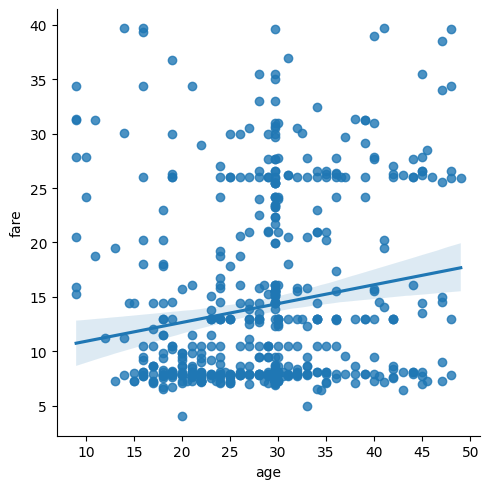

In [271]:
sns.lmplot(data=df_linear, x = 'age', y='fare')

<Axes: ylabel='age'>

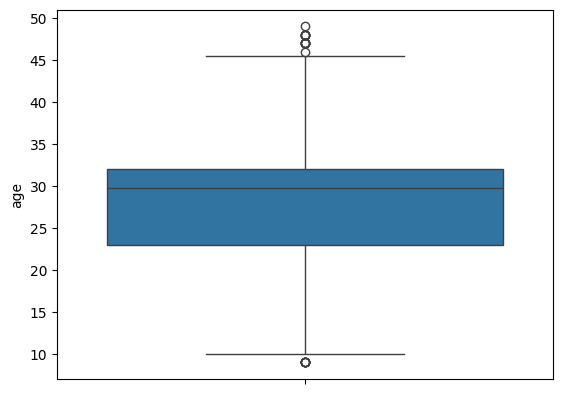

In [272]:
sns.boxplot(data= df_linear, y='age')

In [273]:
df_linear =df_linear[(df_linear['age'] >5) & (df_linear['age'] < 55)]

<Axes: ylabel='age'>

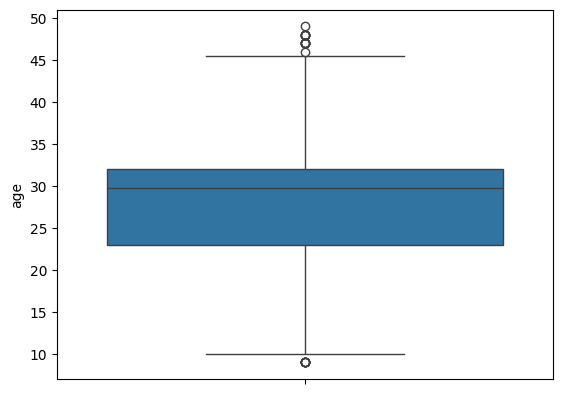

In [274]:
sns.boxplot(data= df_linear, y='age')

In [275]:
df_linear =df_linear[(df_linear['age'] >8) & (df_linear['age'] < 50)]

<Axes: ylabel='age'>

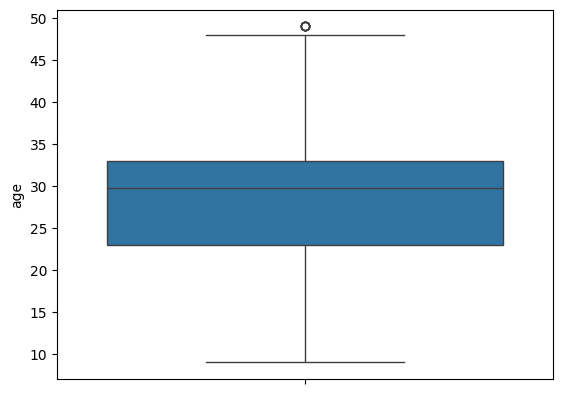

In [247]:
sns.boxplot(data= df_linear, y='age')

<Axes: ylabel='fare'>

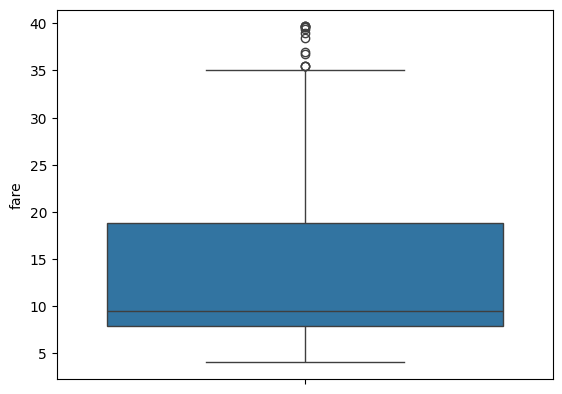

In [276]:
sns.boxplot(data= df_linear, y='fare')

In [279]:
df_linear.min()

age     9.0000
fare    4.0125
dtype: float64

In [277]:
df_linear =df_linear[(df_linear['fare'] >1) & (df_linear['fare'] < 40)]

<Axes: ylabel='fare'>

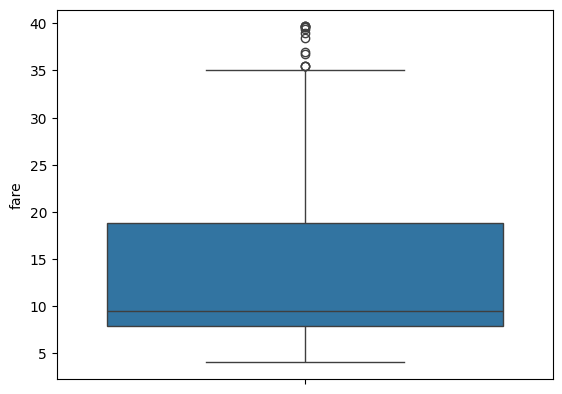

In [278]:
sns.boxplot(data= df_linear, y='fare')

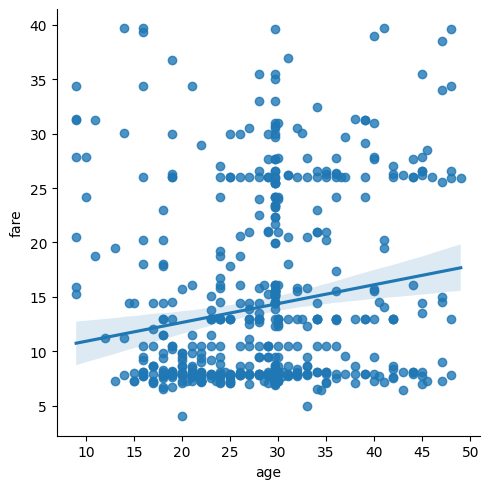

In [280]:
sns.lmplot(data=df_linear, x = 'age', y='fare')

In [ ]:
X = df_linear[['age']]
y = df_linear['fare']

In [286]:
# call the model
model = LinearRegression()
# train the model
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [283]:
model.predict([[25]])

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.51193182])

In [284]:
model.predict([[80]])

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([23.05317906])

In [290]:
# model evaluation with matrics if predictions sre true or not
# r2
# mean squared error
# MEA
# RMSE

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8)

# model
model = LinearRegression()

# train
model.fit(X_train, y_train)

# prediction
predictions = model.predict(X_test)

<Axes: xlabel='fare'>

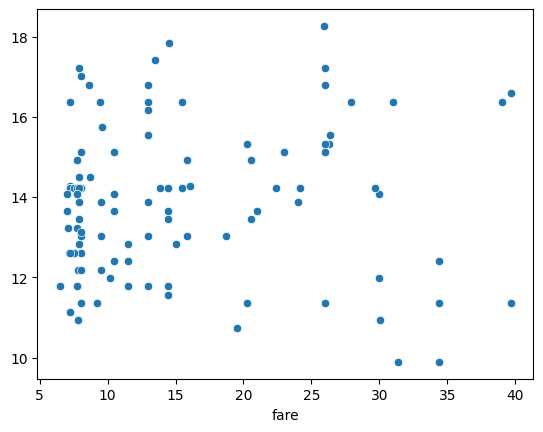

In [293]:

# Compare actual vs predicted

sns.scatterplot(x = y_test, y=predictions)

In [295]:
model.score(X_test,y_test)

-0.026588782960889956